In [35]:
import numpy as np 
import pandas as pd

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/breast-cancer-prediction/data (1).csv


In [24]:
# Step 1: Import libraries
import pandas as pd
from sklearn.datasets import load_breast_cancer

# Step 2: Load the dataset
data = load_breast_cancer()

# Step 3: Create a DataFrame
df = pd.DataFrame(data.data, columns=data.feature_names)
df['target'] = data.target

# Step 4: See what it looks like
df.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


In [25]:
# handle the missing value 

# Shape of dataset
print("Shape:", df.shape)

# Check for missing values
print("\nMissing values:\n", df.isnull().sum().head())

# Target balance
print("\nTarget value counts:\n", df['target'].value_counts())

# Basic statistics
df.describe().T.head()


Shape: (569, 31)

Missing values:
 mean radius        0
mean texture       0
mean perimeter     0
mean area          0
mean smoothness    0
dtype: int64

Target value counts:
 target
1    357
0    212
Name: count, dtype: int64


,count,mean,std,min,25%,50%,75%,max
mean radius,569.0,14.127292,3.524049,6.98100,11.70000,13.37000,15.7800,28.1100
mean texture,569.0,19.289649,4.301036,9.71000,16.17000,18.84000,21.8000,39.2800
mean perimeter,569.0,91.969033,24.298981,43.79000,75.17000,86.24000,104.1000,188.5000
mean area,569.0,654.889104,351.914129,143.50000,420.30000,551.10000,782.7000,2501.0000
mean smoothness,569.0,0.096360,0.014064,0.05263,0.08637,0.09587,0.1053,0.1634


In [26]:
df['target'].value_counts()


target
1    357
0    212
Name: count, dtype: int64

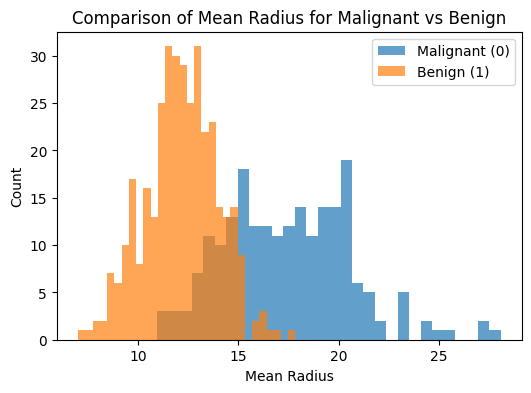

In [27]:
import matplotlib.pyplot as plt

# Simple visualization
plt.figure(figsize=(6,4))
plt.hist(df[df['target']==0]['mean radius'], bins=30, alpha=0.7, label='Malignant (0)')
plt.hist(df[df['target']==1]['mean radius'], bins=30, alpha=0.7, label='Benign (1)')
plt.xlabel('Mean Radius')
plt.ylabel('Count')
plt.legend()
plt.title('Comparison of Mean Radius for Malignant vs Benign')
plt.show()


In [28]:
#load the data
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# 1. Separate features and target
X = df.drop('target', axis=1)
y = df['target']

# 2. Split data: 80% train, 20% test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Scale the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)



In [29]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# 1. Create and train the model
model = LogisticRegression()
model.fit(X_train_scaled, y_train)

# 2. Predict on test data
y_pred = model.predict(X_test_scaled)

# 3. Evaluate performance
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))


Accuracy: 0.9736842105263158

Classification Report:
               precision    recall  f1-score   support

           0       0.98      0.95      0.96        43
           1       0.97      0.99      0.98        71

    accuracy                           0.97       114
   macro avg       0.97      0.97      0.97       114
weighted avg       0.97      0.97      0.97       114


Confusion Matrix:
 [[41  2]
 [ 1 70]]


In [30]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(random_state=42)
rf.fit(X_train_scaled, y_train)
y_pred_rf = rf.predict(X_test_scaled)

print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("\nClassification Report:\n", classification_report(y_test, y_pred_rf))


Accuracy: 0.9649122807017544

Classification Report:
               precision    recall  f1-score   support

           0       0.98      0.93      0.95        43
           1       0.96      0.99      0.97        71

    accuracy                           0.96       114
   macro avg       0.97      0.96      0.96       114
weighted avg       0.97      0.96      0.96       114



In [31]:
new_data=pd.read_csv("/kaggle/input/breast-cancer-prediction/data (1).csv")
# new_data.head()
# new_data.info()


In [32]:
# 1. Separate the features (as before)
new_features = new_data.drop(columns=['id', 'diagnosis', 'Unnamed: 32'])

# 2. Separate the actual labels (as before)
new_labels = new_data['diagnosis']

# Get the list of original, correct column names from cell 6
original_column_names = X.columns 

# 4. Assign those original names to our new data's columns
new_features.columns = original_column_names

# 5. NOW we can scale it, and it will work
new_features_scaled = scaler.transform(new_features)

print("Column names fixed! Data scaled successfully.")

Column names fixed! Data scaled successfully.


In [33]:
#Make predictions on the new, unseen data
new_predictions = model.predict(new_features_scaled)

# Let's map the predictions (0s and 1s) to our labels
predicted_labels = ['Malignant' if p == 0 else 'Benign' for p in new_predictions]

# Let's print the first 10 predictions to see what they look like
print(new_predictions[:10])

if new_predictions[0] == 0:
    print("🔴 The Breast Cancer is Malignant")
else:
    print("🟢 The Breast Cancer is Benign")

[0 0 0 0 0 0 0 0 0 0]
🔴 The Breast Cancer is Malignant
